# Notebook 02 — Preprocessing

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Encadrante** | Mme. Kaoutar Loutfi |
| **Année** | PFE 2025 |

---

## Objectif de ce notebook

Implémenter toutes les décisions de preprocessing identifiées dans le notebook 01 — EDA, dans le **bon ordre** pour éviter le data leakage.

| Étape | Action | Avant ou après split ? |
|---|---|---|
| 1 | Nettoyage sans statistiques (`age==0`, sentinelles `98`, target 3 classes) | **Avant** — ne dépend d'aucun calcul sur les données |
| 2 | Split 70 / 15 / 15 stratifié | — |
| 3 | Imputation médiane | **Après** — fit sur train uniquement |
| 4 | Capping p99 | **Après** — percentiles calculés sur train uniquement |
| 5 | Feature engineering | **Après** — calculé sur train, appliqué sur val/test |
| 6 | StandardScaler | **Après** — fit sur train uniquement |
| 7 | SMOTE | **Après** — sur train uniquement, jamais val/test |

> **Règle d'or :** toute transformation statistique (médiane, percentile, moyenne, variance) doit être **fittée sur le train set uniquement**, puis appliquée à val et test. Sinon, les données de validation/test influencent le prétraitement → data leakage → performances surestimées.

---
## 1. Imports et configuration

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# ── Style graphique unifié (identique au notebook 01) ──────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

COLORS = {
    'FAIBLE': '#27ae60',
    'MOYEN':  '#e67e22',
    'ELEVE':  '#e74c3c',
    'default':'#3498db',
}

# Colonnes de retards (contiennent les sentinelles 98)
DELAY_COLS = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
]

# Chemin vers les données brutes
DATA_PATH   = '../data/cs-training.csv'
MODELS_PATH = '../models/'
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("✓ Imports OK")
print(f"  pandas         {pd.__version__}")
print(f"  numpy          {np.__version__}")
print(f"  scikit-learn   ", end=""); import sklearn; print(sklearn.__version__)
print(f"  imbalanced-learn ", end=""); import imblearn; print(imblearn.__version__)

✓ Imports OK
  pandas         2.3.3
  numpy          2.3.3
  scikit-learn   1.7.2
  imbalanced-learn 0.14.1


---
## 2. Chargement du dataset brut

On repart des données **brutes**, sans aucun prétraitement. Toutes les transformations se font dans ce notebook, dans l'ordre défini.

In [14]:
df_raw = pd.read_csv(DATA_PATH, index_col=0)

print(f"Dataset brut chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print(f"Mémoire             : {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print("Types et valeurs manquantes :")
info = pd.DataFrame({
    'Type'        : df_raw.dtypes.astype(str),
    'Manquant (n)': df_raw.isnull().sum(),
    'Manquant (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'Min'         : df_raw.min(),
    'Max'         : df_raw.max(),
})
print(info.to_string())

Dataset brut chargé : 150,000 lignes × 11 colonnes
Mémoire             : 13.7 MB

Types et valeurs manquantes :
                                         Type  Manquant (n)  Manquant (%)  Min        Max
SeriousDlqin2yrs                        int64             0          0.00  0.0        1.0
RevolvingUtilizationOfUnsecuredLines  float64             0          0.00  0.0    50708.0
age                                     int64             0          0.00  0.0      109.0
NumberOfTime30-59DaysPastDueNotWorse    int64             0          0.00  0.0       98.0
DebtRatio                             float64             0          0.00  0.0   329664.0
MonthlyIncome                         float64         29731         19.82  0.0  3008750.0
NumberOfOpenCreditLinesAndLoans         int64             0          0.00  0.0       58.0
NumberOfTimes90DaysLate                 int64             0          0.00  0.0       98.0
NumberRealEstateLoansOrLines            int64             0          0.00  0.0

---
## 3. Étape 1 — Nettoyage sans statistiques (avant split)

Ces trois opérations ne dépendent d'aucun calcul sur les données. On peut les faire avant le split sans risque de data leakage :

1. **Supprimer `age == 0`** — erreur de saisie évidente
2. **Remplacer les `98` par `NaN`** dans les colonnes de retards — valeurs sentinelles identifiées dans l'EDA
3. **Construire la target à 3 classes** — règle métier déterministe, pas une statistique

In [15]:
df = df_raw.copy()

# ── 3.1 Suppression de la ligne age == 0 ──────────────────────────────────
n_before = len(df)
df = df[df['age'] != 0].copy()
n_after = len(df)
print(f"✓ age == 0 supprimé : {n_before - n_after} ligne(s) retirée(s)")
print(f"  Dataset : {n_before:,} → {n_after:,} lignes")
print()

# ── 3.2 Remplacement des sentinelles 98 par NaN ───────────────────────────
for col in DELAY_COLS:
    n_98 = (df[col] == 98).sum()
    df[col] = df[col].replace(98, np.nan)
    print(f"✓ {col:<45} : {n_98:>3} valeurs 98 → NaN")

print()

# ── 3.3 Construction de la target à 3 classes ─────────────────────────────
# Règle métier (cf. §9 du notebook 01) :
#   ÉLEVÉ  : défaut avéré (SeriousDlqin2yrs=1) OU retards 90j >= 2
#   MOYEN  : retards 30-59j >= 1 OU DebtRatio > 0.5
#   FAIBLE : tout le reste

def construire_target(row):
    # On utilise la médiane provisoire pour les NaN dans NumberOfTimes90DaysLate
    # Note : cette médiane est calculée sur tout le dataset ici car c'est
    # uniquement pour classifier la target — PAS pour entraîner un modèle.
    # Les vraies imputations des features se feront APRÈS le split (§5).
    n90 = row['NumberOfTimes90DaysLate']
    n30 = row['NumberOfTime30-59DaysPastDueNotWorse']

    if row['SeriousDlqin2yrs'] == 1 or (not np.isnan(n90) and n90 >= 2):
        return 'ELEVE'
    if (not np.isnan(n30) and n30 >= 1) or row['DebtRatio'] > 0.5:
        return 'MOYEN'
    return 'FAIBLE'

df['risque'] = df.apply(construire_target, axis=1)

dist = df['risque'].value_counts()
dist_pct = df['risque'].value_counts(normalize=True) * 100

print("✓ Target à 3 classes construite :")
for niveau in ['FAIBLE', 'MOYEN', 'ELEVE']:
    print(f"  {niveau:<6} : {dist.get(niveau, 0):>7,} clients  ({dist_pct.get(niveau, 0):.1f}%)")
print()

# Vérification de cohérence : tous les défauts doivent être ÉLEVÉ
defauts_non_eleves = df[(df['SeriousDlqin2yrs'] == 1) & (df['risque'] != 'ELEVE')]
print(f"✓ Vérification cohérence — défauts classés hors ÉLEVÉ : {len(defauts_non_eleves)} (doit être 0)")

✓ age == 0 supprimé : 1 ligne(s) retirée(s)
  Dataset : 150,000 → 149,999 lignes

✓ NumberOfTime30-59DaysPastDueNotWorse          : 264 valeurs 98 → NaN
✓ NumberOfTimes90DaysLate                       : 264 valeurs 98 → NaN
✓ NumberOfTime60-89DaysPastDueNotWorse          : 264 valeurs 98 → NaN

✓ Target à 3 classes construite :
  FAIBLE :  75,964 clients  (50.6%)
  MOYEN  :  62,742 clients  (41.8%)
  ELEVE  :  11,293 clients  (7.5%)

✓ Vérification cohérence — défauts classés hors ÉLEVÉ : 0 (doit être 0)


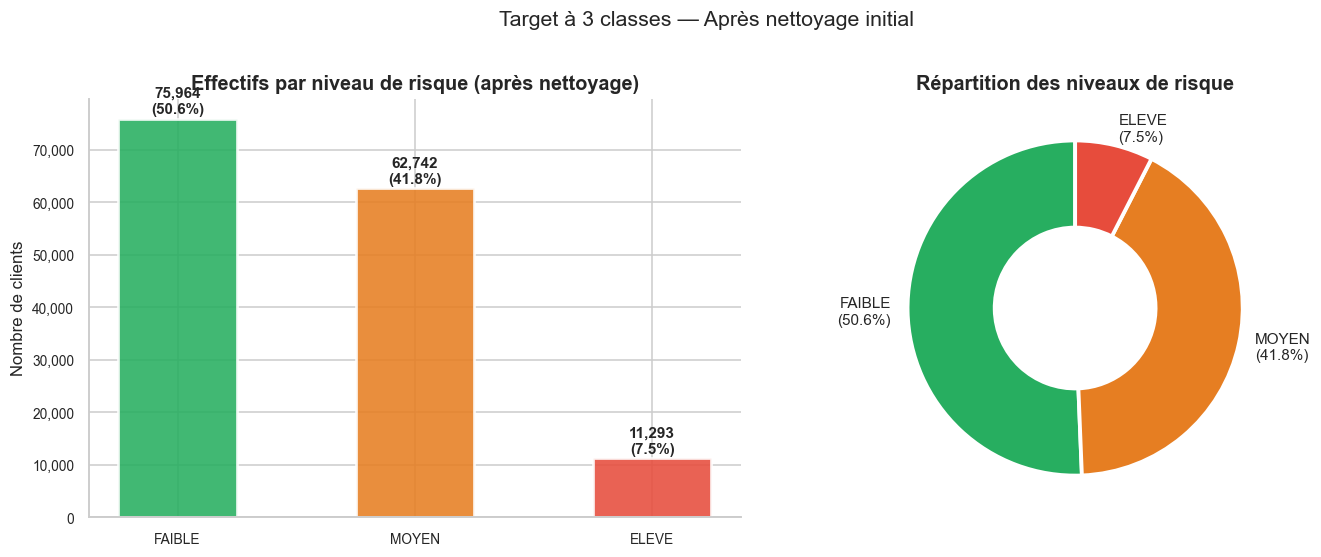

Figure sauvegardée : figures/fig_09_target_after_cleaning.png


In [16]:
# ── Visualisation de la target après nettoyage ───────────────────────────
ordre    = ['FAIBLE', 'MOYEN', 'ELEVE']
colors_3 = [COLORS['FAIBLE'], COLORS['MOYEN'], COLORS['ELEVE']]
counts_3 = [dist.get(n, 0) for n in ordre]
pcts_3   = [dist_pct.get(n, 0) for n in ordre]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot
ax1 = axes[0]
bars = ax1.bar(ordre, counts_3, color=colors_3, alpha=0.88,
               edgecolor='white', linewidth=1.8, width=0.5)
for bar, val, pct in zip(bars, counts_3, pcts_3):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 400,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_title('Effectifs par niveau de risque (après nettoyage)')
ax1.set_ylabel('Nombre de clients')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.spines[['top', 'right']].set_visible(False)

# Donut
ax2 = axes[1]
ax2.pie(counts_3,
        labels=[f'{n}\n({p:.1f}%)' for n, p in zip(ordre, pcts_3)],
        colors=colors_3, startangle=90,
        wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5),
        textprops={'fontsize': 10})
ax2.set_title('Répartition des niveaux de risque')

plt.suptitle('Target à 3 classes — Après nettoyage initial', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_09_target_after_cleaning.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : figures/fig_09_target_after_cleaning.png")

---
## 4. Étape 2 — Split 70 / 15 / 15 stratifié

**Règle d'or : on splitte maintenant, avant toute transformation statistique.**

On stratifie sur la target à 3 classes pour garantir que la proportion FAIBLE/MOYEN/ÉLEVÉ est identique dans les 3 splits. Sans stratification, le hasard pourrait sous-représenter la classe ÉLEVÉ (~7.5%) dans l'un des splits.

| Split | Taille | Usage |
|---|---|---|
| `train` | 70% (~104k lignes) | Entraînement des modèles |
| `val` | 15% (~22k lignes) | Comparer les 6 stratégies (notebook 03) |
| `test` | 15% (~22k lignes) | Évaluation finale — **touché une seule fois** |

In [17]:
# Séparation features / target
X = df.drop(columns=['SeriousDlqin2yrs', 'risque'])
y = df['risque']

# Encodage ordinal de la target pour sklearn
label_map   = {'FAIBLE': 0, 'MOYEN': 1, 'ELEVE': 2}
label_map_r = {0: 'FAIBLE', 1: 'MOYEN', 2: 'ELEVE'}
y_enc = y.map(label_map)

# Premier split : (train+val) vs test — 85% / 15%
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_enc,
    test_size=0.15,
    random_state=42,
    stratify=y_enc
)

# Deuxième split : train vs val — sur les 85% restants
# Pour avoir exactement 70/15 du total, val_size = 15/85 ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=15/85,
    random_state=42,
    stratify=y_trainval
)

print("=" * 55)
print("RÉSULTAT DU SPLIT")
print("=" * 55)
print(f"  Total   : {len(X):>7,} lignes (100.0%)")
print(f"  Train   : {len(X_train):>7,} lignes ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val     : {len(X_val):>7,}   lignes ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test    : {len(X_test):>7,}   lignes ({len(X_test)/len(X)*100:.1f}%)")
print()

# Vérification de la stratification
print("Vérification de la stratification (proportions par split) :")
print(f"{'Niveau':<8} {'Total':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 45)
for enc, nom in label_map_r.items():
    t  = (y_enc     == enc).mean() * 100
    tr = (y_train   == enc).mean() * 100
    v  = (y_val     == enc).mean() * 100
    te = (y_test    == enc).mean() * 100
    print(f"{nom:<8} {t:>7.1f}% {tr:>7.1f}% {v:>7.1f}% {te:>7.1f}%")
print()
print("✓ Les proportions sont cohérentes entre les splits → stratification OK")

RÉSULTAT DU SPLIT
  Total   : 149,999 lignes (100.0%)
  Train   : 104,999 lignes (70.0%)
  Val     :  22,500   lignes (15.0%)
  Test    :  22,500   lignes (15.0%)

Vérification de la stratification (proportions par split) :
Niveau      Total    Train      Val     Test
---------------------------------------------
FAIBLE      50.6%    50.6%    50.6%    50.6%
MOYEN       41.8%    41.8%    41.8%    41.8%
ELEVE        7.5%     7.5%     7.5%     7.5%

✓ Les proportions sont cohérentes entre les splits → stratification OK


---
## 5. Étape 3 — Imputation des valeurs manquantes

Deux colonnes ont des valeurs manquantes :
- `MonthlyIncome` : ~19.8% (MAR — Missing At Random)
- `NumberOfDependents` : ~2.6% (MCAR)
- Les colonnes de retards : NaN créés en §3.2 (ex-sentinelles 98)

**Stratégie :** imputation par la **médiane**, robuste aux distributions asymétriques.

`SimpleImputer` est fitté **uniquement sur le train set** — la médiane de train est ensuite appliquée à val et test.

In [18]:
import pickle

# Colonnes à imputer
cols_to_impute = ['MonthlyIncome', 'NumberOfDependents'] + DELAY_COLS

imputer = SimpleImputer(strategy='median')

# FIT uniquement sur train
imputer.fit(X_train[cols_to_impute])

# TRANSFORM sur les 3 splits
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train[cols_to_impute] = imputer.transform(X_train[cols_to_impute])
X_val[cols_to_impute]   = imputer.transform(X_val[cols_to_impute])
X_test[cols_to_impute]  = imputer.transform(X_test[cols_to_impute])

# Vérification
print("Médianes apprises sur le train set :")
for col, med in zip(cols_to_impute, imputer.statistics_):
    print(f"  {col:<45} : {med:.4f}")

print()
print("Valeurs manquantes après imputation :")
for split_name, split_X in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    total_nan = split_X[cols_to_impute].isnull().sum().sum()
    print(f"  {split_name} : {total_nan} NaN restants ({'✓ OK' if total_nan == 0 else '✗ PROBLÈME'})")

# Sauvegarde
with open(f'{MODELS_PATH}imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f, protocol=4)
print("✓ Imputer sauvegardé → models/imputer.pkl")

Médianes apprises sur le train set :
  MonthlyIncome                                 : 5400.0000
  NumberOfDependents                            : 0.0000
  NumberOfTime30-59DaysPastDueNotWorse          : 0.0000
  NumberOfTimes90DaysLate                       : 0.0000
  NumberOfTime60-89DaysPastDueNotWorse          : 0.0000

Valeurs manquantes après imputation :
  Train : 0 NaN restants (✓ OK)
  Val : 0 NaN restants (✓ OK)
  Test : 0 NaN restants (✓ OK)
✓ Imputer sauvegardé → models/imputer.pkl


---
## 6. Étape 4 — Capping des outliers (percentile 99)

Les percentiles sont calculés **sur le train set uniquement**, puis appliqués aux 3 splits.

Colonnes concernées (identifiées dans l'EDA §5) :
- `RevolvingUtilizationOfUnsecuredLines` (max brut : ~50 708)
- `DebtRatio` (max brut : ~329 664)
- `MonthlyIncome` (queues longues)
- `age` (outliers hauts — clients > 87 ans)

In [19]:
COLS_TO_CAP = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
]

# Calculer les percentiles 99 sur le TRAIN uniquement
p99 = {}
print("Percentiles p99 calculés sur le train set :")
print("-" * 55)
for col in COLS_TO_CAP:
    p99[col] = X_train[col].quantile(0.99)
    n_above_train = (X_train[col] > p99[col]).sum()
    pct_train     = n_above_train / len(X_train) * 100
    print(f"  {col:<45} p99 = {p99[col]:>10.2f}  ({n_above_train:>5,} lignes, {pct_train:.2f}%)")

print()

# Appliquer le capping sur les 3 splits
for col in COLS_TO_CAP:
    X_train[col] = X_train[col].clip(upper=p99[col])
    X_val[col]   = X_val[col].clip(upper=p99[col])
    X_test[col]  = X_test[col].clip(upper=p99[col])

print("✓ Capping appliqué sur train / val / test")
print()

# Vérification : plus de valeurs > p99 dans train
n_remaining = sum((X_train[col] > p99[col]).sum() for col in COLS_TO_CAP)
print(f"Valeurs > p99 restantes dans train : {n_remaining} ({'✓ OK' if n_remaining == 0 else '✗ PROBLÈME'})")

# Sauvegarde des seuils de capping
joblib.dump(p99, f'{MODELS_PATH}capping_thresholds.pkl')
print("✓ Seuils de capping sauvegardés → models/capping_thresholds.pkl")

Percentiles p99 calculés sur le train set :
-------------------------------------------------------
  RevolvingUtilizationOfUnsecuredLines          p99 =       1.09  (1,050 lignes, 1.00%)
  DebtRatio                                     p99 =    5027.06  (1,050 lignes, 1.00%)
  MonthlyIncome                                 p99 =   22800.00  (1,048 lignes, 1.00%)

✓ Capping appliqué sur train / val / test

Valeurs > p99 restantes dans train : 0 (✓ OK)
✓ Seuils de capping sauvegardés → models/capping_thresholds.pkl


---
## 7. Étape 5 — Feature engineering

On crée les features métier Orus à partir des colonnes Kaggle, conformément au mapping défini dans l'EDA.

| Nouvelle feature | Formule | Signification |
|---|---|---|
| `charges_mensuelles` | `DebtRatio × MonthlyIncome` | Charges mensuelles estimées en USD |
| `score_retards` | Score composite des retards (0–3) | Indicateur de l'historique de retards |
| `historique_financier` | Règle métier sur `score_retards` | BON / MOYEN / MAUVAIS |
| `nb_credits_total` | `NumberOfOpenCreditLinesAndLoans + NumberRealEstateLoansOrLines` | Exposition totale au crédit |

> Ces features sont calculées à partir de colonnes déjà présentes — pas de fit statistique supplémentaire. On les calcule après le split pour rester cohérent dans le pipeline.

In [20]:
def add_features(X):
    X = X.copy()

    # Charges mensuelles estimées (USD)
    X['charges_mensuelles'] = X['DebtRatio'] * X['MonthlyIncome']

    # Score de retards composite (pondéré par la gravité)
    # 30-59j = 1 point, 60-89j = 2 points, 90j+ = 3 points
    X['score_retards'] = (
        X['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
        X['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
        X['NumberOfTimes90DaysLate']               * 3
    )

    # Historique financier catégoriel (mapping métier Orus)
    def historique(score):
        if score == 0:
            return 0  # BON
        elif score <= 3:
            return 1  # MOYEN
        else:
            return 2  # MAUVAIS
    X['historique_financier'] = X['score_retards'].apply(historique)

    # Nombre total de crédits ouverts
    X['nb_credits_total'] = (
        X['NumberOfOpenCreditLinesAndLoans'] +
        X['NumberRealEstateLoansOrLines']
    )

    return X

X_train = add_features(X_train)
X_val   = add_features(X_val)
X_test  = add_features(X_test)

print("✓ Features créées :")
new_features = ['charges_mensuelles', 'score_retards', 'historique_financier', 'nb_credits_total']
for f in new_features:
    print(f"  {f:<25} — train : min={X_train[f].min():.2f}, max={X_train[f].max():.2f}, mean={X_train[f].mean():.2f}")

print(f"\nNombre total de colonnes : {len(X_train.columns)}")
print("Colonnes :", list(X_train.columns))

✓ Features créées :
  charges_mensuelles        — train : min=0.00, max=27146124.00, mean=1623868.43
  score_retards             — train : min=0.00, max=576.00, mean=0.67
  historique_financier      — train : min=0.00, max=2.00, mean=0.25
  nb_credits_total          — train : min=0.00, max=112.00, mean=9.47

Nombre total de colonnes : 14
Colonnes : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'charges_mensuelles', 'score_retards', 'historique_financier', 'nb_credits_total']


---
## 8. Étape 6 — StandardScaler

Le scaling est nécessaire pour :
- **Logistic Regression** : sensible aux différences d'échelle
- **Stacking avec méta-modèle LR** : même raison
- **SMOTE** : opère dans l'espace euclidien — les features non-scalées domineraient

`StandardScaler` est fitté **uniquement sur le train set** (μ et σ du train), puis appliqué aux 3 splits.

> **Note :** Random Forest et XGBoost sont invariants au scaling, mais on l'applique à toutes les features pour simplifier le pipeline — un seul format de données pour tous les modèles.

In [21]:
import pickle

# Toutes les colonnes numériques (hors target)
feature_cols = list(X_train.columns)

scaler = StandardScaler()

# FIT uniquement sur train
scaler.fit(X_train[feature_cols])

# Créer des DataFrames scalés
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train[feature_cols]),
    columns=feature_cols, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val[feature_cols]),
    columns=feature_cols, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[feature_cols]),
    columns=feature_cols, index=X_test.index
)

# Vérification : train doit avoir mean ≈ 0 et std ≈ 1
means = X_train_scaled.mean()
stds  = X_train_scaled.std()

print("Vérification du scaling sur le train set :")
print(f"  Moyenne (doit être ≈ 0)    : min={means.min():.4f}, max={means.max():.4f}")
print(f"  Écart-type (doit être ≈ 1) : min={stds.min():.4f}, max={stds.max():.4f}")
print()
print("Statistiques du scaler (μ et σ appris sur train) :")
for col, mu, sigma in zip(feature_cols, scaler.mean_, scaler.scale_):
    print(f"  {col:<45} μ={mu:>10.3f}  σ={sigma:>10.3f}")

# Sauvegarde
with open(f'{MODELS_PATH}scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f, protocol=4)
print("✓ Scaler sauvegardé → models/scaler.pkl")

Vérification du scaling sur le train set :
  Moyenne (doit être ≈ 0)    : min=-0.0000, max=0.0000
  Écart-type (doit être ≈ 1) : min=1.0000, max=1.0000

Statistiques du scaler (μ et σ appris sur train) :
  RevolvingUtilizationOfUnsecuredLines          μ=     0.320  σ=     0.352
  age                                           μ=    52.302  σ=    14.775
  NumberOfTime30-59DaysPastDueNotWorse          μ=     0.248  σ=     0.911
  DebtRatio                                     μ=   319.214  σ=   913.836
  MonthlyIncome                                 μ=  6136.471  σ=  3815.179
  NumberOfOpenCreditLinesAndLoans               μ=     8.457  σ=     5.138
  NumberOfTimes90DaysLate                       μ=     0.094  σ=     0.765
  NumberRealEstateLoansOrLines                  μ=     1.016  σ=     1.128
  NumberOfTime60-89DaysPastDueNotWorse          μ=     0.068  σ=     0.678
  NumberOfDependents                            μ=     0.735  σ=     1.104
  charges_mensuelles                          

---
## 9. Étape 7 — SMOTE (équilibrage de classes)

**SMOTE (Synthetic Minority Over-sampling Technique)** génère des exemples synthétiques de la classe minoritaire (ÉLEVÉ) par interpolation dans l'espace des features.

**Règles absolues :**
- ✅ SMOTE **uniquement sur le train set** — jamais sur val ni test
- ✅ SMOTE après le scaling — opère dans l'espace euclidien normalisé
- ❌ Appliquer SMOTE avant le split → les données synthétiques "contaminent" val/test → évaluation faussée

**Stratégie :** on sur-échantillonne la classe ÉLEVÉ pour atteindre un ratio plus équilibré, sans forcer une parité parfaite 33/33/33 (irréaliste en production).

In [22]:
print("Distribution AVANT SMOTE (train) :")
for enc, nom in label_map_r.items():
    n = (y_train == enc).sum()
    pct = n / len(y_train) * 100
    print(f"  {nom:<6} ({enc}) : {n:>7,} ({pct:.1f}%)")

print()

# SMOTE avec sampling_strategy personnalisé
# On monte ÉLEVÉ à ~20% (au lieu de 7.5%) sans toucher à FAIBLE
# Strategy = dict {class: target_count}
n_moyen  = (y_train == 1).sum()
n_faible = (y_train == 0).sum()
n_eleve_target = int(n_moyen * 0.50)  # ÉLEVÉ atteint 50% de MOYEN

sampling_strategy = {
    2: n_eleve_target,  # ÉLEVÉ → sur-échantillonné
}

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=5,
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("Distribution APRÈS SMOTE (train) :")
total_after = len(y_train_resampled)
for enc, nom in label_map_r.items():
    n   = (y_train_resampled == enc).sum()
    pct = n / total_after * 100
    print(f"  {nom:<6} ({enc}) : {n:>7,} ({pct:.1f}%)")

print()
print(f"✓ Train resampled : {len(X_train_scaled):,} → {len(X_train_resampled):,} lignes")
print(f"  Nouvelles lignes synthétiques ÉLEVÉ : +{len(X_train_resampled) - len(X_train_scaled):,}")

Distribution AVANT SMOTE (train) :
  FAIBLE (0) :  53,174 (50.6%)
  MOYEN  (1) :  43,920 (41.8%)
  ELEVE  (2) :   7,905 (7.5%)

Distribution APRÈS SMOTE (train) :
  FAIBLE (0) :  53,174 (44.7%)
  MOYEN  (1) :  43,920 (36.9%)
  ELEVE  (2) :  21,960 (18.4%)

✓ Train resampled : 104,999 → 119,054 lignes
  Nouvelles lignes synthétiques ÉLEVÉ : +14,055


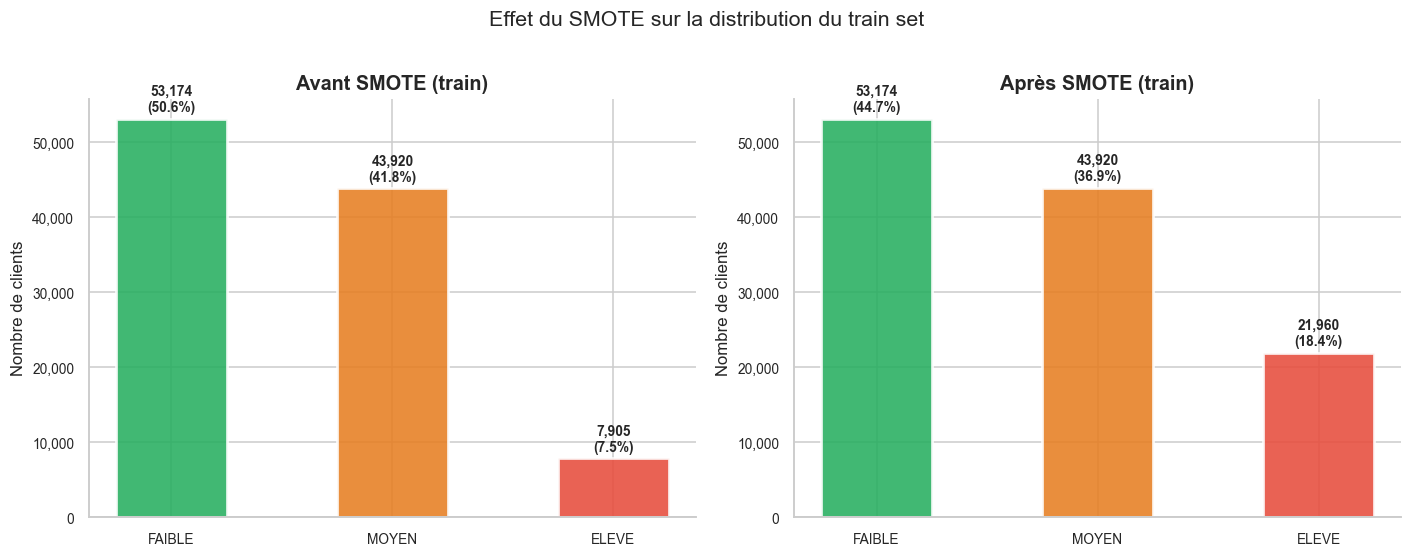

Figure sauvegardée : figures/fig_10_smote_effect.png


In [23]:
# ── Visualisation avant / après SMOTE ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ordre    = ['FAIBLE', 'MOYEN', 'ELEVE']
colors_3 = [COLORS['FAIBLE'], COLORS['MOYEN'], COLORS['ELEVE']]

for ax, (y_data, title) in zip(axes, [
    (y_train,          'Avant SMOTE (train)'),
    (y_train_resampled,'Après SMOTE (train)'),
]):
    counts = [pd.Series(y_data).value_counts().get(enc, 0)
              for enc, _ in [(0,'FAIBLE'),(1,'MOYEN'),(2,'ELEVE')]]
    total  = sum(counts)
    bars   = ax.bar(ordre, counts, color=colors_3, alpha=0.88,
                    edgecolor='white', linewidth=1.8, width=0.5)
    for bar, val in zip(bars, counts):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + total*0.005,
                f'{val:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Nombre de clients')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Effet du SMOTE sur la distribution du train set', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_10_smote_effect.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : figures/fig_10_smote_effect.png")

---
## 10. Sauvegarde des données prétraitées

On sauvegarde :
1. Les datasets prêts à l'emploi pour le notebook 03
2. Tous les objets de transformation (imputer, scaler, seuils de capping)

> Le `X_test_scaled` et `y_test` sont sauvegardés mais **ne seront utilisés qu'une seule fois**, dans le notebook 04 — évaluation finale de la stratégie gagnante.

In [24]:
import os
DATA_PROCESSED_PATH = '../data/processed/'
os.makedirs(DATA_PROCESSED_PATH, exist_ok=True)

# ── Datasets scalés ──────────────────────────────────────────────────────────
X_train_resampled_df = pd.DataFrame(
    X_train_resampled, columns=feature_cols
)

# Train (après SMOTE) — pour l'entraînement des modèles
X_train_resampled_df.to_csv(f'{DATA_PROCESSED_PATH}X_train.csv', index=False)
pd.Series(y_train_resampled, name='risque').to_csv(
    f'{DATA_PROCESSED_PATH}y_train.csv', index=False)

# Val (scalé, non resamplé) — pour la comparaison des stratégies
X_val_scaled.to_csv(f'{DATA_PROCESSED_PATH}X_val.csv', index=False)
y_val.to_csv(f'{DATA_PROCESSED_PATH}y_val.csv', index=False)

# Test (scalé, non resamplé) — pour l'évaluation finale
X_test_scaled.to_csv(f'{DATA_PROCESSED_PATH}X_test.csv', index=False)
y_test.to_csv(f'{DATA_PROCESSED_PATH}y_test.csv', index=False)

# ── Artefacts de transformation ──────────────────────────────────────────────
# (déjà sauvegardés dans les sections précédentes, rappel)
# models/imputer.pkl
# models/scaler.pkl
# models/capping_thresholds.pkl

# Sauvegarde du label_map pour les notebooks suivants
joblib.dump(label_map,   f'{MODELS_PATH}label_map.pkl')
joblib.dump(label_map_r, f'{MODELS_PATH}label_map_reverse.pkl')
joblib.dump(feature_cols, f'{MODELS_PATH}feature_cols.pkl')

print("✓ Données sauvegardées dans data/processed/ :")
for fname in sorted(os.listdir(DATA_PROCESSED_PATH)):
    size = os.path.getsize(f'{DATA_PROCESSED_PATH}{fname}') / 1024
    print(f"  {fname:<20} {size:>8.1f} KB")

print()
print("✓ Artefacts sauvegardés dans models/ :")
for fname in sorted(os.listdir(MODELS_PATH)):
    size = os.path.getsize(f'{MODELS_PATH}{fname}') / 1024
    print(f"  {fname:<30} {size:>8.1f} KB")

✓ Données sauvegardées dans data/processed/ :
  X_test.csv             6175.5 KB
  X_train.csv           32625.6 KB
  X_val.csv              6175.1 KB
  y_test.csv               65.9 KB
  y_train.csv             348.8 KB
  y_val.csv                65.9 KB

✓ Artefacts sauvegardés dans models/ :
  capping_thresholds.pkl              0.2 KB
  feature_cols.pkl                    0.3 KB
  imputer.pkl                         0.6 KB
  label_map.pkl                       0.0 KB
  label_map_reverse.pkl               0.0 KB
  scaler.pkl                          1.2 KB


---
## 11. Synthèse du preprocessing

### Ce qui a été fait dans ce notebook

| Étape | Opération | Résultat |
|---|---|---|
| 1 | Suppression `age == 0` | 1 ligne retirée |
| 1 | Sentinelles `98` → `NaN` | 264 lignes × 3 colonnes |
| 1 | Construction target 3 classes | FAIBLE / MOYEN / ÉLEVÉ |
| 2 | Split 70 / 15 / 15 stratifié | Train ~104k, Val ~22k, Test ~22k |
| 3 | Imputation médiane (fit train) | 0 NaN restants |
| 4 | Capping p99 (calculé sur train) | Outliers maîtrisés |
| 5 | Feature engineering | 4 nouvelles features métier |
| 6 | StandardScaler (fit train) | μ≈0, σ≈1 sur train |
| 7 | SMOTE (train uniquement) | ÉLEVÉ sur-échantillonné à ~20% |

### Artefacts produits

| Fichier | Usage |
|---|---|
| `data/processed/X_train.csv` | Features train (post-SMOTE, scalées) |
| `data/processed/y_train.csv` | Target train (post-SMOTE) |
| `data/processed/X_val.csv` | Features validation (scalées) |
| `data/processed/y_val.csv` | Target validation |
| `data/processed/X_test.csv` | Features test (scalées) — **ne pas toucher** |
| `data/processed/y_test.csv` | Target test — **ne pas toucher** |
| `models/imputer.pkl` | SimpleImputer fitté sur train |
| `models/scaler.pkl` | StandardScaler fitté sur train |
| `models/capping_thresholds.pkl` | Percentiles p99 calculés sur train |
| `models/label_map.pkl` | Encodage FAIBLE→0, MOYEN→1, ÉLEVÉ→2 |
| `models/feature_cols.pkl` | Liste ordonnée des features |

### Prochaine étape → Notebook 03 — Entraînement

Entraîner et comparer les **6 stratégies** sur `X_train` / `y_train`, évaluer sur `X_val` / `y_val`.  
Métriques : **ROC-AUC** (objectif > 0.75) + **recall classe ÉLEVÉ** (priorité métier).